In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from scipy.stats import zscore, boxcox

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

import warnings
warnings.filterwarnings('ignore')

In [4]:
usahousing = pd.read_csv(r"C:\Users\saiha\OneDrive\Documents\Python\APPLIEDDATASCIENCEwithPYTHON\USA_Housing.csv")

In [5]:
usahousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [6]:
usahousing.shape

(5000, 7)

In [7]:
usahousing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [8]:
usahousing.columns=usahousing.columns.str.replace(' ','_')

In [9]:
usahousing.columns

Index(['Avg._Area_Income', 'Avg._Area_House_Age', 'Avg._Area_Number_of_Rooms',
       'Avg._Area_Number_of_Bedrooms', 'Area_Population', 'Price', 'Address'],
      dtype='object')

In [10]:
usahousing.columns=usahousing.columns.str.replace('.','')

In [11]:
usahousing.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price', 'Address'],
      dtype='object')

In [12]:
usahousing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Avg_Area_Income              4990 non-null   float64
 1   Avg_Area_House_Age           5000 non-null   float64
 2   Avg_Area_Number_of_Rooms     4995 non-null   float64
 3   Avg_Area_Number_of_Bedrooms  4994 non-null   float64
 4   Area_Population              5000 non-null   float64
 5   Price                        5000 non-null   float64
 6   Address                      5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [13]:
usahousing.describe()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,4990.000000,5000.000000,4995.000000,4994.000000,5000.000000,5.000000e+03
mean,68584.719991,5.977222,6.987693,3.981874,36163.516039,1.232073e+06
std,10651.192423,0.991456,1.005938,1.234497,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.465105,5.322283,6.299156,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75779.145465,6.650808,7.665622,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [14]:
#unique values of only this column
usahousing['Avg_Area_House_Age'].unique()

array([5.68286132, 6.00289981, 5.86588984, ..., 7.25059062, 5.53438842,
       5.99230531], shape=(5000,))

In [15]:
#unique values for every column
for col in usahousing.columns:
    print("**********", col, "**********")
    print(usahousing[col].unique())
    print()

********** Avg_Area_Income **********
[79545.45857 79248.64245 61287.06718 ... 63390.68689 68001.33124
 65510.5818 ]

********** Avg_Area_House_Age **********
[5.68286132 6.00289981 5.86588984 ... 7.25059062 5.53438842 5.99230531]

********** Avg_Area_Number_of_Rooms **********
[7.00918814 6.73082102 8.51272743 ... 4.80508098 7.13014386 6.7923361 ]

********** Avg_Area_Number_of_Bedrooms **********
[4.09 3.09 5.13 3.26 4.23 4.04 3.41 2.42 2.3  6.1  4.1  4.49  nan 5.12
 5.49 4.07 2.1  4.31 6.34 4.33 2.03 4.   3.04 3.24 4.42 5.36 6.29 6.
 2.07 3.01 2.39 2.5  2.17 6.3  4.43 4.44 6.32 3.18 6.35 3.22 2.13 4.02
 6.36 3.32 4.12 6.41 5.08 4.01 3.06 2.28 4.2  4.32 5.43 3.13 3.28 3.27
 3.08 3.17 3.15 6.25 3.43 4.38 6.16 4.28 4.11 6.24 3.35 4.48 3.2  3.07
 3.39 3.38 6.06 3.3  3.46 3.33 4.41 2.38 2.37 3.45 2.02 4.37 2.14 2.23
 2.44 2.29 4.19 6.04 5.28 5.1  5.45 3.1  4.36 2.05 6.39 4.45 4.22 6.44
 4.35 3.37 6.2  6.19 2.49 2.04 4.46 5.15 3.21 6.45 3.44 2.18 3.49 6.26
 4.14 4.27 5.04 4.06 6.4  3.25 5

In [16]:
#total no. of unique values of every column
for col in usahousing.columns:
    print("*********", col, "**********")
    print("Unique Values :", usahousing[col].nunique())
    print()

********* Avg_Area_Income **********
Unique Values : 4990

********* Avg_Area_House_Age **********
Unique Values : 5000

********* Avg_Area_Number_of_Rooms **********
Unique Values : 4995

********* Avg_Area_Number_of_Bedrooms **********
Unique Values : 255

********* Area_Population **********
Unique Values : 5000

********* Price **********
Unique Values : 5000

********* Address **********
Unique Values : 5000



In [17]:
#address is non-significant to predict housing price so we can drop this
usahousing_clean = usahousing.drop('Address', axis=1)
usahousing_clean.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price'],
      dtype='object')

In [18]:
#ANOVA TESTING TO CHECK SIGNIFICANT VARIABLE as it gives 'P'value whose valuae gives us idea about the relvance of that variable. 
# Since Address have p value > 5% ,So we can drop it as it is less significant.

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Price ~ Avg_Area_Income', data = usahousing_clean).fit()
#sets up the formula how price is predicted by the avg_area_income points to dataset usahousing_clean and trains .fit() model.
anova_res = sm.stats.anova_lm(model, typ=2)
print(anova_res)


                       sum_sq      df            F  PR(>F)
Avg_Area_Income  2.546601e+14     1.0  3455.920442     0.0
Residual         3.675561e+14  4988.0          NaN     NaN


In [19]:
# typ = 2 --> we are ignoring any interaction between two features, means, x1,x2 but not in x1.x2
# typ = 1 Sequence matters
# typ = 3 interaction can not be ignored.

In [20]:
# As  p value is less than SL(significance level) so we can reject the null hypothesis: Means--> there is significant relation between price and Avg_Area_Income 

In [21]:
model = ols('Price ~ Area_Population', data = usahousing_clean).fit()
anova_res = sm.stats.anova_lm(model, typ = 2)
print(anova_res)
#rejected the null-hypothesis --> significant feature

                       sum_sq      df            F         PR(>F)
Area_Population  1.040459e+14     1.0  1001.408749  1.736392e-200
Residual         5.192897e+14  4998.0          NaN            NaN


In [22]:
model = ols('Price ~ Avg_Area_House_Age', data = usahousing_clean).fit()
anova_res = sm.stats.anova_lm(model, typ = 2)
print(anova_res)
#rejected the null-hypothesis --> significant feature

                          sum_sq      df            F         PR(>F)
Avg_Area_House_Age  1.276559e+14     1.0  1287.169756  4.944750e-251
Residual            4.956797e+14  4998.0          NaN            NaN


In [23]:
#to find missing values
usahousing_clean.isnull().sum()

Avg_Area_Income                10
Avg_Area_House_Age              0
Avg_Area_Number_of_Rooms        5
Avg_Area_Number_of_Bedrooms     6
Area_Population                 0
Price                           0
dtype: int64

In [24]:
usahousing_clean.isnull().sum()/len(usahousing)*100

Avg_Area_Income                0.20
Avg_Area_House_Age             0.00
Avg_Area_Number_of_Rooms       0.10
Avg_Area_Number_of_Bedrooms    0.12
Area_Population                0.00
Price                          0.00
dtype: float64

In [25]:
# To check presence of OUTLIER and decide what to use either mean or median to impute missing value we can use boxplot
# -If there are outliers use median else go with mean

In [26]:
# humare paas teen features mein nan values hai to unn teeno ke boxplot bana diye

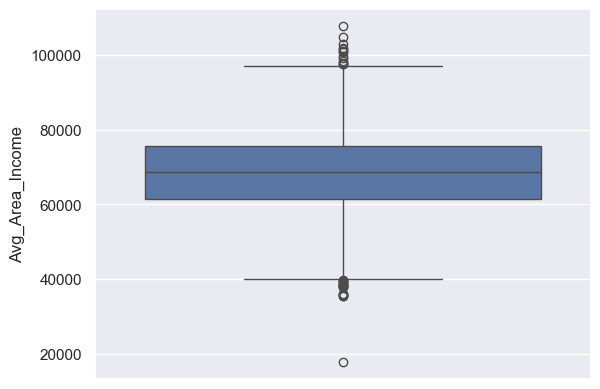

In [27]:
sns.boxplot(y = 'Avg_Area_Income' , data = usahousing_clean)
plt.show()

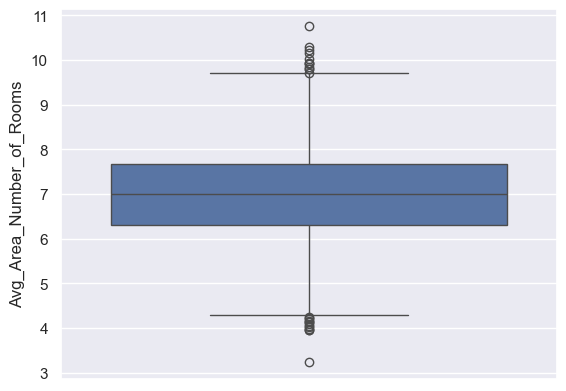

In [28]:
sns.boxplot(y = 'Avg_Area_Number_of_Rooms' , data = usahousing_clean)
plt.show()

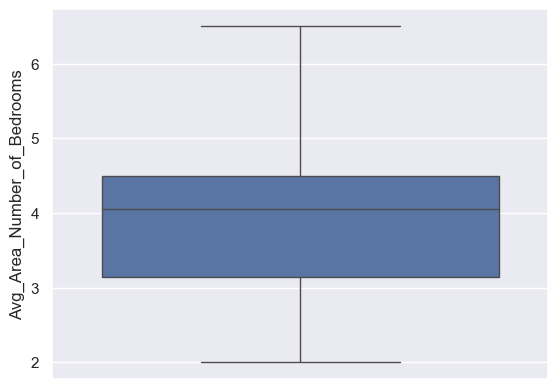

In [29]:
sns.boxplot(y = 'Avg_Area_Number_of_Bedrooms' , data = usahousing_clean)
plt.show()

In [30]:
# as there are outliers, we will use median

usahousing_clean['Avg_Area_Income'] = usahousing_clean['Avg_Area_Income'].fillna( usahousing_clean['Avg_Area_Income'].median())
usahousing_clean['Avg_Area_Number_of_Rooms'] = usahousing_clean['Avg_Area_Number_of_Rooms'].fillna( usahousing_clean['Avg_Area_Number_of_Rooms'].median())
usahousing_clean['Avg_Area_Number_of_Bedrooms'] = usahousing_clean['Avg_Area_Number_of_Bedrooms'].fillna( usahousing_clean['Avg_Area_Number_of_Bedrooms'].median())

In [31]:
usahousing_clean.isnull().sum()

Avg_Area_Income                0
Avg_Area_House_Age             0
Avg_Area_Number_of_Rooms       0
Avg_Area_Number_of_Bedrooms    0
Area_Population                0
Price                          0
dtype: int64

In [32]:
# Distribution plots to check whether data is normally distributed or not.
# ----> no of bed room have non normal data.

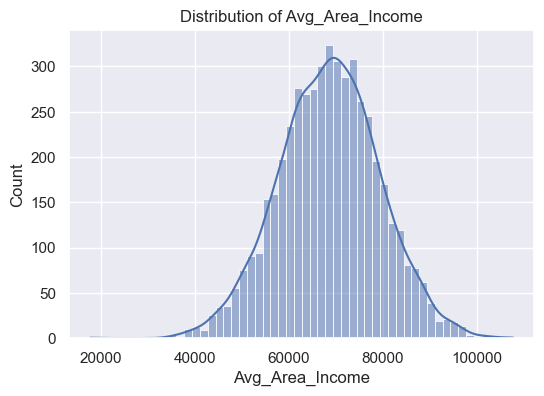

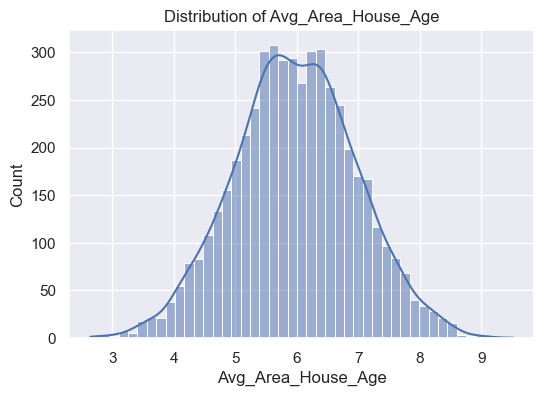

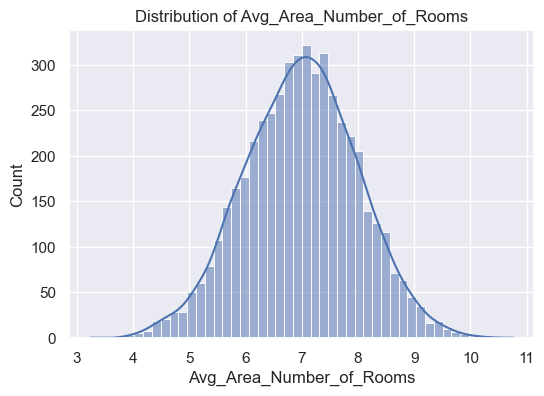

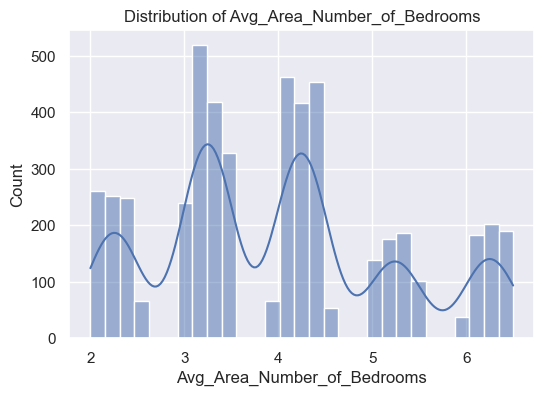

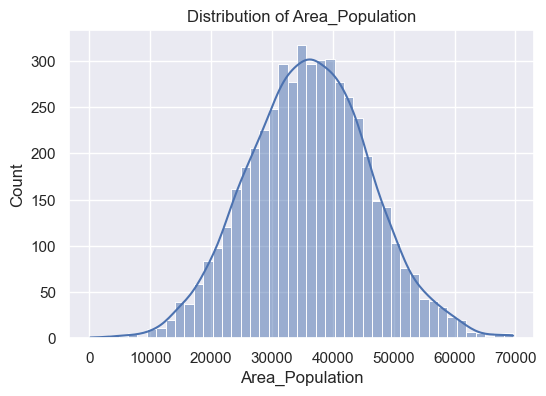

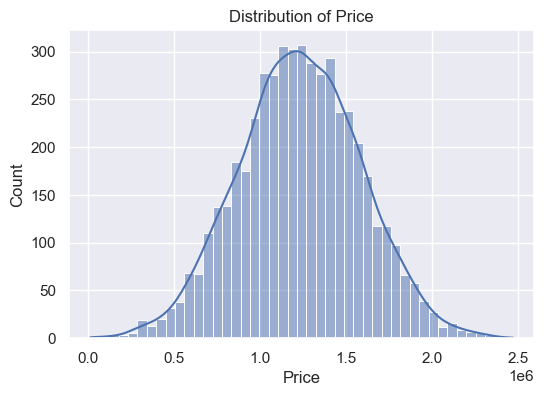

In [33]:
def distplots(col):
    plt.figure(figsize=(6,4))
    sns.histplot(usahousing_clean[col], kde=True)  #kde shows the smooth curves
    plt.title(f"Distribution of {col}")
    plt.show()

for col in usahousing_clean.columns :
    distplots(col)

# The distribution shows clustered patterns, which is expected since bedroom counts are inherently discrete. Normality of predictors is not required for linear regression

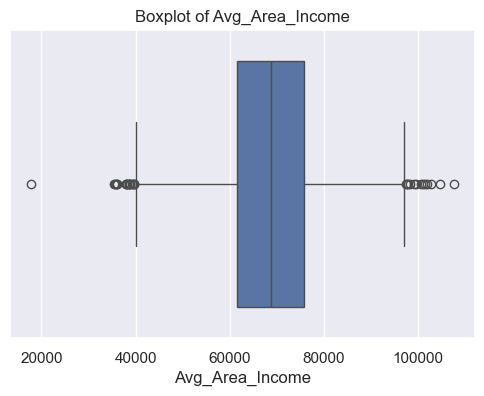

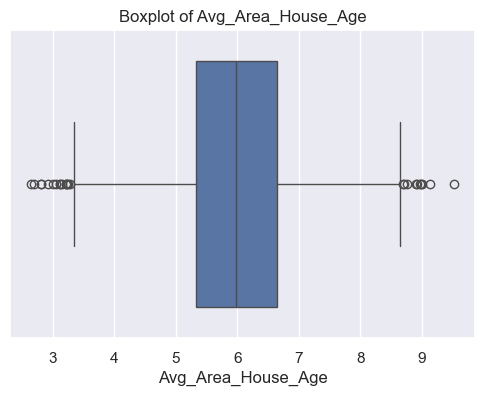

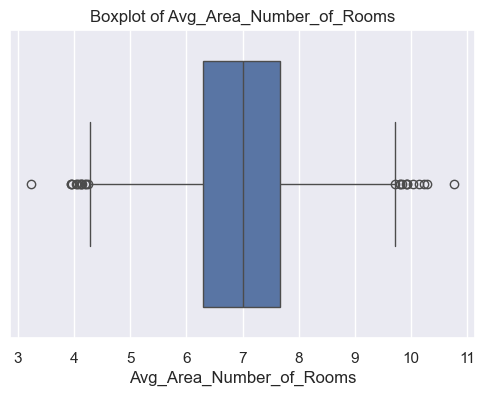

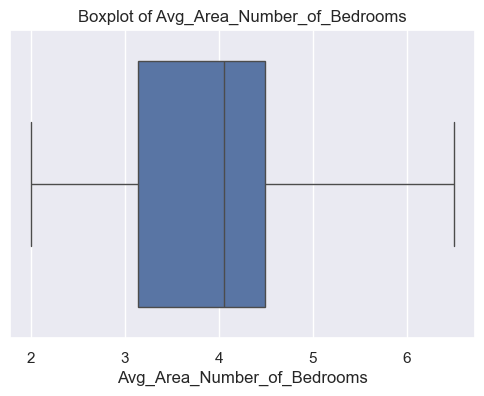

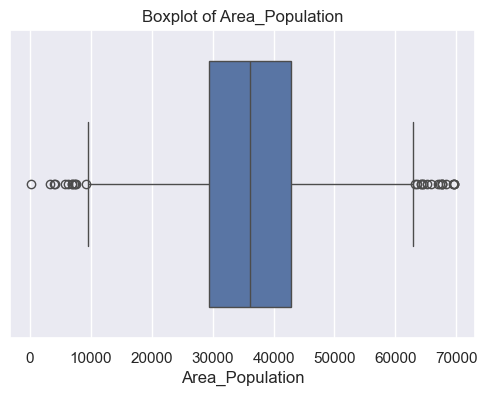

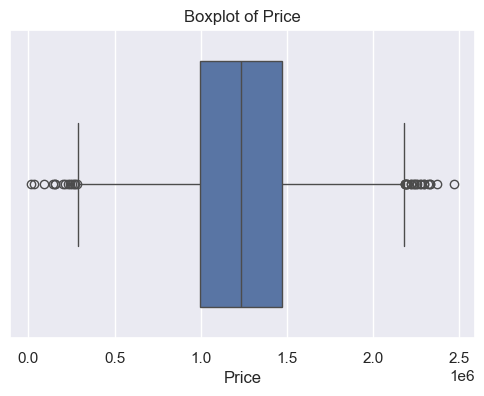

In [34]:
# to view outliers we use boxplot

def boxplots(col) :
    plt.figure(figsize=(6,4))
    sns.boxplot(x=usahousing_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in usahousing_clean.select_dtypes(exclude=['object']).columns:boxplots(col)

In [35]:
# find Q1, ,Q3 ,IQR, Upper Limit,Lower limit to handle outliers
# don't touch the dependent variables (price) for outliers

In [36]:
Q1 = usahousing_clean.quantile(0.25)
Q3 = usahousing_clean.quantile(0.75)
IQR = Q3 - Q1
UL = Q3 + 1.5*IQR
LL = Q1 - 1.5*IQR

In [37]:
print('Q1')
print(Q1)
print('******'*5)
print('Q3')
print(Q3)
print('******'*5)   
print('IQR')
print(IQR)
print('******'*5)  
print('Upper_Limit')
print(UL)
print('******'*5) 
print('Lower_Limit')
print(LL)

Q1
Avg_Area_Income                 61485.150192
Avg_Area_House_Age                  5.322283
Avg_Area_Number_of_Rooms            6.299692
Avg_Area_Number_of_Bedrooms         3.140000
Area_Population                 29403.928700
Price                          997577.135075
Name: 0.25, dtype: float64
******************************
Q3
Avg_Area_Income                7.576652e+04
Avg_Area_House_Age             6.650808e+00
Avg_Area_Number_of_Rooms       7.665281e+00
Avg_Area_Number_of_Bedrooms    4.490000e+00
Area_Population                4.286129e+04
Price                          1.471210e+06
Name: 0.75, dtype: float64
******************************
IQR
Avg_Area_Income                 14281.368910
Avg_Area_House_Age                  1.328525
Avg_Area_Number_of_Rooms            1.365589
Avg_Area_Number_of_Bedrooms         1.350000
Area_Population                 13457.362070
Price                          473633.069425
dtype: float64
******************************
Upper_Limit
Avg_Area_Inc

In [38]:
outliers = ((usahousing_clean < LL) | (usahousing_clean > UL) )

outliers.sum()

Avg_Area_Income                31
Avg_Area_House_Age             25
Avg_Area_Number_of_Rooms       25
Avg_Area_Number_of_Bedrooms     0
Area_Population                30
Price                          35
dtype: int64

In [39]:
# use capping to handle outliers

Income_Q1 =usahousing_clean['Avg_Area_Income'].quantile(0.25)
Income_Q3 = usahousing_clean['Avg_Area_Income'].quantile(0.75)
Income_IQR = Income_Q3 - Income_Q1
Income_Upper =Income_Q3 + Income_IQR*1.5
Income_Lower = Income_Q1 - Income_IQR*1.5

In [40]:
usahousing_clean['Avg_Area_Income'] = usahousing_clean['Avg_Area_Income'].clip(lower = Income_Lower, upper = Income_Upper)

# usahousing_clean['Avg_Area_Income'] = np.where(usahousing_clean['Avg_Area_Income']>Income_Upper,Income_Upper, 
                                              # np.where(usahousing_clean['Avg_Area_Income']<Income_Lower,Income_Lower,
                                                      # usahousing_clean['Avg_Area_Income']))

In [41]:
usahousing_clean['Avg_Area_Income'].describe()

count     5000.000000
mean     68587.479539
std      10574.362055
min      40063.096827
25%      61485.150192
50%      68797.671885
75%      75766.519103
max      97188.572468
Name: Avg_Area_Income, dtype: float64

In [42]:
usahousing['Avg_Area_Income'].describe()

count      4990.000000
mean      68584.719991
std       10651.192423
min       17796.631190
25%       61481.465105
50%       68797.671885
75%       75779.145465
max      107701.748400
Name: Avg_Area_Income, dtype: float64

In [43]:
Age_Q1 = usahousing_clean['Avg_Area_House_Age'].quantile(0.25)
Age_Q3 = usahousing_clean['Avg_Area_House_Age'].quantile(0.75)
Age_IQR = Age_Q3 - Age_Q1
Age_Upper =Age_Q3 + Age_IQR*1.5
Age_Lower = Age_Q1 - Age_IQR*1.5

In [44]:
usahousing_clean['Avg_Area_House_Age'] = usahousing_clean['Avg_Area_House_Age'].clip(lower = Age_Lower, upper = Age_Upper)

In [45]:
usahousing_clean['Avg_Area_House_Age'].describe()

count    5000.000000
mean        5.977490
std         0.986995
min         3.329495
25%         5.322283
50%         5.970429
75%         6.650808
max         8.643597
Name: Avg_Area_House_Age, dtype: float64

In [46]:
Number_of_Rooms_Q1 = usahousing_clean['Avg_Area_Number_of_Rooms'].quantile(0.25)
Number_of_Rooms_Q3 = usahousing_clean['Avg_Area_Number_of_Rooms'].quantile(0.75)
Number_of_Rooms_IQR = Number_of_Rooms_Q3 - Number_of_Rooms_Q1
Number_of_Rooms_Upper =Number_of_Rooms_Q3 + Number_of_Rooms_IQR*1.5
Number_of_Rooms_Lower = Number_of_Rooms_Q1 - Number_of_Rooms_IQR*1.5

In [47]:
usahousing_clean['Avg_Area_Number_of_Rooms'] = usahousing_clean['Avg_Area_Number_of_Rooms'].clip(lower = Number_of_Rooms_Lower, upper = Number_of_Rooms_Upper)

In [48]:
Population_Q1 = usahousing_clean['Area_Population'].quantile(0.25)
Population_Q3 = usahousing_clean['Area_Population'].quantile(0.75)
Population_IQR = Population_Q3 - Population_Q1
Population_Upper =Population_Q3 + Population_IQR*1.5
Population_Lower = Population_Q1 - Population_IQR*1.5

In [49]:
usahousing_clean['Area_Population'] = usahousing_clean['Area_Population'].clip(lower = Population_Lower, upper = Population_Upper)

In [50]:
usahousing_clean.describe()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68587.479539,5.977490,6.987540,3.981956,36159.070769,1.232073e+06
std,10574.362055,0.986995,1.001419,1.233758,9862.221143,3.531176e+05
min,40063.096827,3.329495,4.251308,2.000000,9217.885595,1.593866e+04
25%,61485.150192,5.322283,6.299692,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75766.519103,6.650808,7.665281,4.490000,42861.290770,1.471210e+06
max,97188.572468,8.643597,9.713664,6.500000,63047.333875,2.469066e+06


In [51]:
usahousing.describe()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population,Price
count,4990.000000,5000.000000,4995.000000,4994.000000,5000.000000,5.000000e+03
mean,68584.719991,5.977222,6.987693,3.981874,36163.516039,1.232073e+06
std,10651.192423,0.991456,1.005938,1.234497,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.465105,5.322283,6.299156,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75779.145465,6.650808,7.665622,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


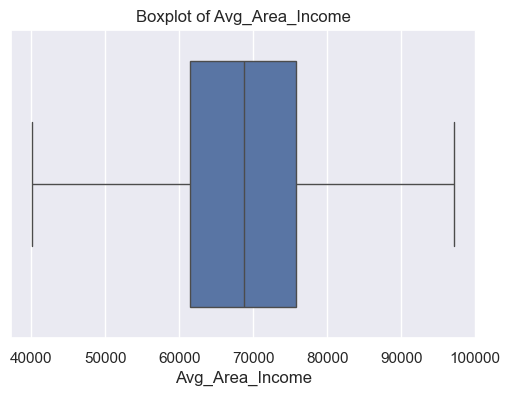

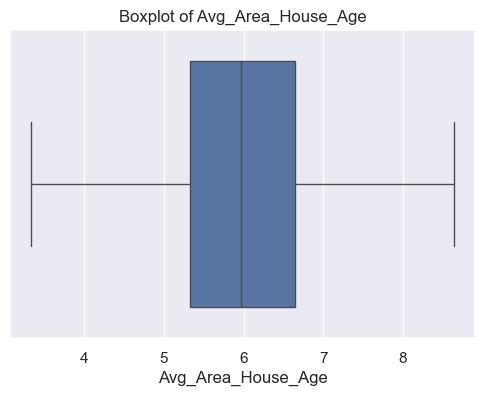

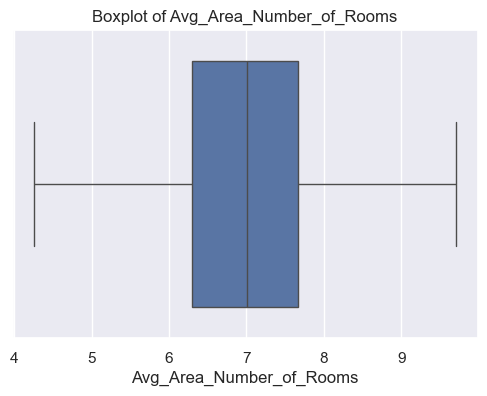

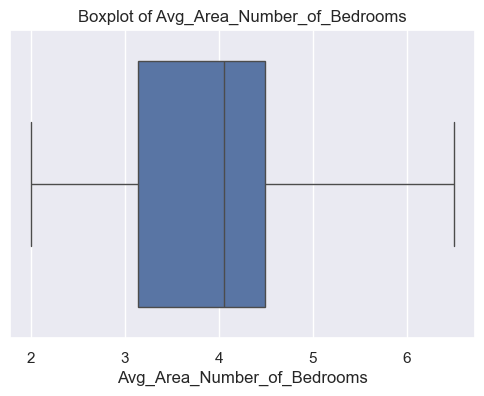

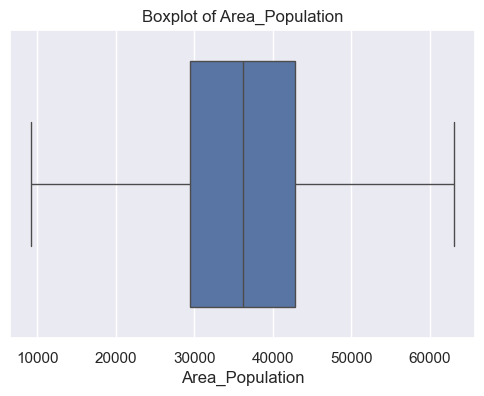

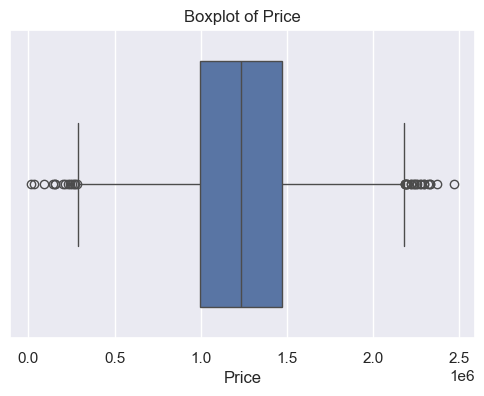

In [52]:
#again check the outliers

def boxplots(col):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=usahousing_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in usahousing_clean.select_dtypes(exclude=['object']).columns:
    boxplots(col)    

In [53]:
usahousing_clean.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price'],
      dtype='object')

In [54]:
# - Find Correlation to check multicolinearity.
# - if value is greater than 0.75 or 0.8, drop than column as it is highly corelated
# - If any of two independent variables have same value than drop any one with discussion by SME. As it leads to multicolinearity.

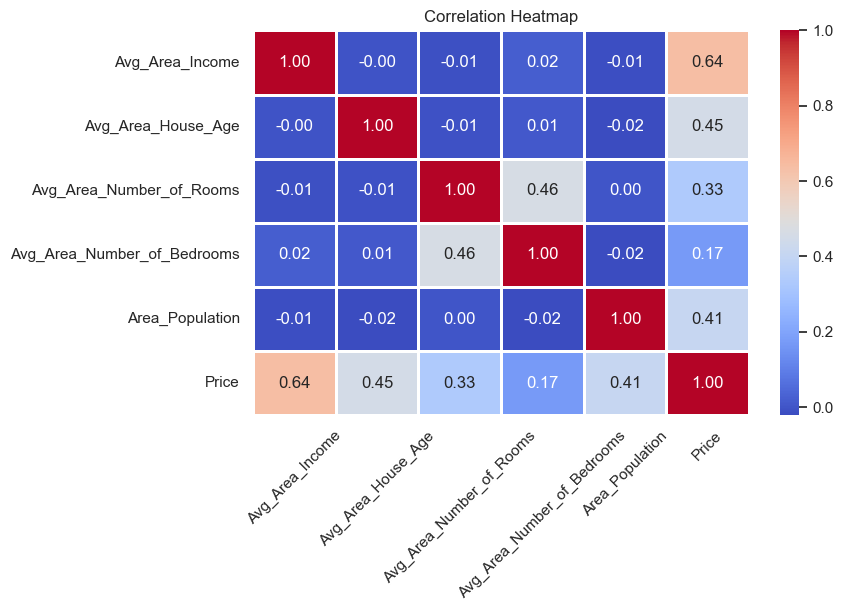

In [55]:
plt.figure(figsize=(8,5))
corr = usahousing_clean.corr()

sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 1)

plt.title("Correlation Heatmap")
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.show()

In [56]:
#split data as X and Y

x = usahousing_clean.drop('Price', axis = 1)    #all the independent variables
y = usahousing_clean[['Price']]                 #dependent variable

print("x : ", x)
print("y : ", y)

x :        Avg_Area_Income  Avg_Area_House_Age  Avg_Area_Number_of_Rooms  \
0         79545.45857            5.682861                  7.009188   
1         79248.64245            6.002900                  6.730821   
2         61287.06718            5.865890                  8.512727   
3         63345.24005            7.188236                  5.586729   
4         59982.19723            5.040555                  7.839388   
...               ...                 ...                       ...   
4995      60567.94414            7.830362                  6.137356   
4996      78491.27543            6.999135                  6.576763   
4997      63390.68689            7.250591                  4.805081   
4998      68001.33124            5.534388                  7.130144   
4999      65510.58180            5.992305                  6.792336   

      Avg_Area_Number_of_Bedrooms  Area_Population  
0                            4.09      23086.80050  
1                            3.09   

In [57]:
# - Variance_Inflation_Factor(VIF) is another approach to check multicolinearity other than heat map
# VIF- Variance Inflation Factor to check multicolinearity
# - VIF should be <= 5
# - VIF = 1/(1-R*2) # Also called coefficient of determination

In [58]:
import statsmodels.api as sm

x_const = sm.add_constant(x)   #takes dataframe x which has all independent features and appneds a new column names const where every single row has the value 1

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()    #creates a empty dataframe that will hold the final summary table
vif['Feature'] = x_const.columns        #creates a column named "feature" conating all the names of independent feature
vif['VIF'] = [variance_inflation_factor(x_const.values, i) for i in range(x_const. shape[1])]       

print(vif)

                       Feature         VIF
0                        const  145.516074
1              Avg_Area_Income    1.001067
2           Avg_Area_House_Age    1.000593
3     Avg_Area_Number_of_Rooms    1.274864
4  Avg_Area_Number_of_Bedrooms    1.275727
5              Area_Population    1.001144


In [60]:
# since for any varibale VIF is <5 so there is no multicolinearity, so one assumption satisfied

x.head()

,Avg_Area_Income,Avg_Area_House_Age,Avg_Area_Number_of_Rooms,Avg_Area_Number_of_Bedrooms,Area_Population
0,79545.45857,5.682861,7.009188,4.09,23086.80050
1,79248.64245,6.002900,6.730821,3.09,40173.07217
2,61287.06718,5.865890,8.512727,5.13,36882.15940
3,63345.24005,7.188236,5.586729,3.26,34310.24283
4,59982.19723,5.040555,7.839388,4.23,26354.10947


In [61]:
y.head()

,Price
0,1.059034e+06
1,1.505891e+06
2,1.058988e+06
3,1.260617e+06
4,6.309435e+05


In [62]:
#split the data into training and test for model building and prediction

In [63]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 101)   
#allocates 25% of the data for testing and 75% for training
# random_state = 101 is a random seed that ensures the data splits the exact same way every time you run the code keeping your results reproducible

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3750, 5) (1250, 5) (3750, 1) (1250, 1)


In [64]:
print('x_train', x_train.head())
print('x_test', x_test.head())
print('y_train', y_train.head())
print('y_test', y_test.head())

x_train       Avg_Area_Income  Avg_Area_House_Age  Avg_Area_Number_of_Rooms  \
3430      72102.19465            5.146607                  7.559894   
3979      66484.84424            5.700885                  6.908871   
2153      78286.51791            4.236881                  7.465136   
4764      89687.48482            5.822977                  7.475893   
36        78667.90460            5.470652                  7.780837   

      Avg_Area_Number_of_Bedrooms  Area_Population  
3430                         3.50      18819.28859  
3979                         3.40      28002.64709  
2153                         5.29      42425.77635  
4764                         3.44      33767.33358  
36                           4.10      27637.65655  
x_test       Avg_Area_Income  Avg_Area_House_Age  Avg_Area_Number_of_Rooms  \
1718      66774.99582            5.717143                  7.795215   
2511      62184.53937            4.925758                  7.427689   
345       73643.05730      

In [65]:
# BUILD THE MODEL

# APPROACH 1 : lINEAR REGRESSION

In [66]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[ 21.73,165690.14,121587.07, 1726.21, 15.3 ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg_Area_Income','Avg_Area_House_Age','Avg_Area_Number_of_Rooms', 'Avg_Area_Number_of_Bedrooms','Area_Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-2657921.45]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [67]:
print(lm.intercept_)    #starting point
print("**********")
print(lm.coef_)         #slope of line  -->  2D matrix shape with double [[]]

[-2657921.44640602]
**********
[[2.17329557e+01 1.65690136e+05 1.21587070e+05 1.72620828e+03
  1.53020327e+01]]


In [68]:
#REGRESSION IN COEFFICENT

coef_df = pd.DataFrame({"Feature" : x.columns, "Coefficient" : lm.coef_.flatten()})   
#flatten sqashes the 2D matrix into clean, flat 1D array so Pandas can allign the data perfectly
print(coef_df)

                       Feature    Coefficient
0              Avg_Area_Income      21.732956
1           Avg_Area_House_Age  165690.136486
2     Avg_Area_Number_of_Rooms  121587.069657
3  Avg_Area_Number_of_Bedrooms    1726.208282
4              Area_Population      15.302033


In [69]:
x.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms',
       'Avg_Area_Number_of_Bedrooms', 'Area_Population'],
      dtype='object')

In [70]:
# PREDICTION OF PRICE FOR TEST AND TRAIN

In [71]:
y_pred_price_test = lm.predict(x_test)
#to predict housing price using unseen testing features
y_pred_price_test

array([[1258771.54630259],
       [ 821509.83414808],
       [1743523.44944712],
       ...,
       [1117250.31198148],
       [ 718622.68490114],
       [1518227.07294694]], shape=(1250, 1))

In [72]:
y_pred_price_train = lm.predict(x_train)
# to preidct prices for training features. this is to check how well model learned the training data
y_pred_price_train

array([[ 975014.89364725],
       [1005966.97250819],
       [1311481.65188273],
       ...,
       [ 973733.51952561],
       [ 922475.53232179],
       [2133370.06333532]], shape=(3750, 1))

In [73]:
residuals_train = y_train - y_pred_price_train 
# error --> calc error for each row in training set. residual is the dist. btw actual real-world price(y_train) and what my model guessed(y_t]pred_price_train)

In [74]:
train_res = pd.DataFrame({"Actual" : y_train.values.flatten(), "Predicted" : y_pred_price_train.flatten(), "Residuals" : residuals_train.values.flatten()})
# y_train and residuals are dataframes so we used .values.flatten and y_pred_price_train is a numpy array so we used .flatten only

train_res.head()

,Actual,Predicted,Residuals
0,9.958132e+05,9.750149e+05,20798.322453
1,8.735092e+05,1.005967e+06,-132457.783008
2,1.360502e+06,1.311482e+06,49020.597117
3,1.742351e+06,1.687682e+06,54669.404686
4,1.233220e+06,1.334237e+06,-101016.655189


In [75]:
residuals_test = y_test - y_pred_price_test

In [76]:
test_res = pd.DataFrame({"Actual": y_test.values.flatten(),"Predicted": y_pred_price_test.flatten(),"Residuals": residuals_test.values.flatten()})

test_res.head()

,Actual,Predicted,Residuals
0,1.251689e+06,1.258772e+06,-7082.930303
1,8.730483e+05,8.215098e+05,51538.485452
2,1.696978e+06,1.743523e+06,-46545.786447
3,1.063964e+06,9.716196e+05,92344.673840
4,9.487883e+05,9.944689e+05,-45680.671922


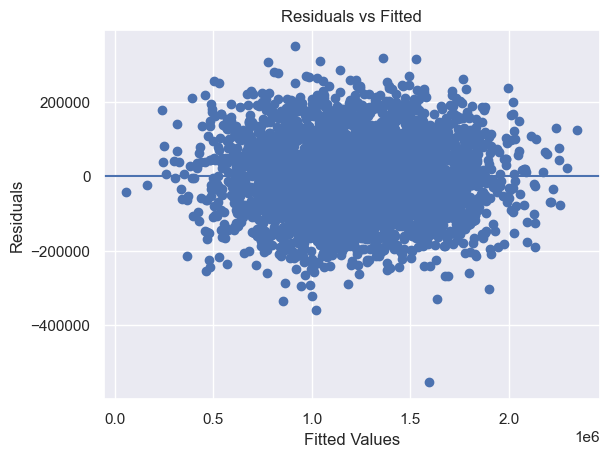

In [77]:
plt.scatter(y_pred_price_train, residuals_train)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [78]:
# VALIDATION FOR TRAIN AND TEST USING R2 SCORE

In [79]:
from sklearn.metrics import r2_score
r2_test = r2_score(y_test, y_pred_price_test)
# FIRST COMES THE ACTUAL DATA THEN THE PREDICTED DATA
# measures how well the model perform on unseen data
print(r2_test)

0.9136249997379459


In [80]:
r2_train = r2_score(y_train, y_pred_price_train)
# measures how well the model fits the data it was actually trained on
print(r2_train)

0.9165094280297815


In [81]:
gap = r2_train - r2_test

if r2_train < 0.50:
    print("Model may be underfitting (high bias).")

elif gap > 0.10 and r2_train > 0.70:
    print("Model may be overfitting (high variance).")

else:
    print("Model appears reasonably balanced.")

Model appears reasonably balanced.


In [82]:
# Since R2 score for training and testing are very close so there no overfitting issue also no underfititng issue

In [83]:
# APPROACH 2 : OLS METHOD

In [84]:
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf

In [85]:
reg_model = smf.OLS(endog = y_train, exog = x_train).fit()
reg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.964
Model:                            OLS   Adj. R-squared (uncentered):              0.964
Method:                 Least Squares   F-statistic:                          2.011e+04
Date:                Fri, 03 Jul 2026   Prob (F-statistic):                        0.00
Time:                        22:30:41   Log-Likelihood:                         -51812.
No. Observations:                3750   AIC:                                  1.036e+05
Df Residuals:                    3745   BIC:                                  1.037e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Avg_Area_Income                10.2091      0.314     32.560      0.000       9.594      10.824
Avg_Area_House_Age           4.916e+04   3478.628     14.131      0.000    4.23e+04     5.6e+04
Avg_Area_Number_of_Rooms     -1.09e+04   3801.792     -2.868      0.004   -1.84e+04   -3448.582
Avg_Area_Number_of_Bedrooms  5109.5344   3631.219      1.407      0.159   -2009.825    1.22e+04
Area_Population                 8.5764      0.382     22.429      0.000       7.827       9.326
==============================================================================
Omnibus:                        0.212   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.899   Jarque-Bera (JB):                0.258
Skew:                          -0.000   Prob(JB):                        0.879
Kurtosis:                       2.959   Cond. No.                     9.32e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 9.32e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [86]:
#  we can check Durbin Watson Test value to check Autocolinearity: change in variable with time
# - DWT < 2 = +ve autocolrelation
# - DWT > 2 = -ve auto corelation
# - DWT = 2 = no auto  corelation
# - If DWT lies between 1.5 to 2.5 model is acceptable else go for timeseries appraoach.


In [87]:
# data should be linear --> let us check the colinearity using scatter ploy

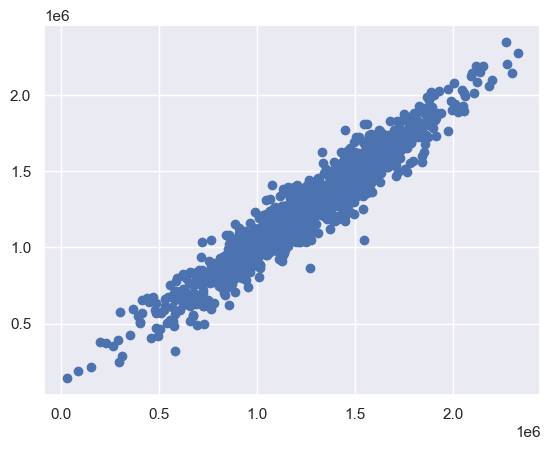

In [88]:
plt.scatter(y_test, y_pred_price_test)

In [89]:
# there is another assumption - normality of residual

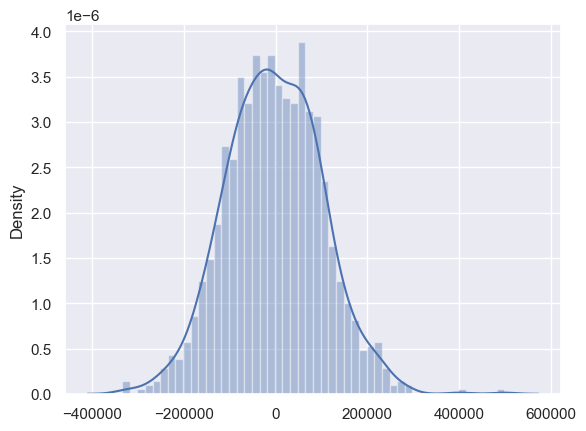

In [90]:
sns.distplot((residuals_test),bins = 50)
plt.show()

In [91]:
# Conclude the model
# - Adj R2 score = 0.96
# - All variable have p value less than 5% except the variable number of bedrooms.So drop it and do it again
# - linearity satisfied
# - Normality of Residual satisifed
# - Homosedasticity satisified
# - No autocorelation satisfied
# - No or little multicolinearity satisfied
# - No endoginity satified

In [92]:
# APPROACH 3 : REGULARIZATION
# shrinking methood to try to find the best combination of coefficient value 

In [93]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.fit_transform(x_test)

In [94]:
print (x_train_sc)
print("*"*65)
print(x_test_sc)

[[ 0.34756384 -0.84626104  0.5801067  -0.37511977 -1.75861417]
 [-0.18594384 -0.27759154 -0.07473731 -0.45647559 -0.82859421]
 [ 0.93491976 -1.77960906  0.48479297  1.08114947  0.63206946]
 ...
 [-1.21765174 -2.2935551  -0.11555534 -1.35138965  2.72046231]
 [-0.51269423 -0.03712923 -1.07599601  0.11301517 -0.35032229]
 [ 0.63026604  1.71677631  1.466108    0.30013356  2.02179631]]
*****************************************************************
[[-0.21012924 -0.27235818  0.77718953  0.22125872  0.07190147]
 [-0.63942101 -1.04638828  0.41770348  1.74755766 -1.02577697]
 [ 0.43216033  0.7543313   1.3072066  -0.56599021  0.71979273]
 ...
 [-1.19291527 -0.15373777  0.8739609  -0.67845434  0.449048  ]
 [-0.46550964 -1.3829853  -1.10034618  0.04452937 -0.31991739]
 [ 0.14012277  0.61881472 -0.83516795  0.34978916  1.58394863]]


In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

In [96]:
# LASSO  --> reduce overfitting, feature selection
# PENALITY PREFERRED = 0.1  --> HYPRERPARAMETER

In [97]:
lasso = Lasso(alpha = 0.1)

In [98]:
lasso.fit(x_train_sc, y_train)
print("Lasso Model :",(lasso.coef_))

Lasso Model : [228828.16295442 161496.72405413 120877.83790438   2121.63241984
 151097.7804182 ]


In [99]:
lasso.intercept_

array([1228547.77983438])

In [100]:
# RIDGE  --> shrink coefficients close to 0
# PREFERRED PENALITY = 0.3  --> HYPERPARAMETER

In [101]:
ridge = Ridge(alpha = 0.3)
ridge.fit(x_train_sc, y_train)
print("Ridge Model :", ridge.coef_)

Ridge Model : [228809.51626678 161483.48120814 120865.06126164   2127.62573703
 151085.8648352 ]


In [102]:
ridge.intercept_

array([1228547.77983438])

In [103]:
y_pred_train_ridge = ridge.predict(x_train_sc)
y_pred_test_ridge = ridge.predict(x_test_sc)

In [104]:
print("Training Accuracy :", r2_score(y_train, y_pred_train_ridge))
print("Test Accuracy :", r2_score(y_test, y_pred_test_ridge))


Training Accuracy : 0.9165094217545875
Test Accuracy : 0.9112131635584613


In [105]:
y_pred_train_lasso = lasso.predict(x_train_sc)
y_pred_test_lasso = lasso.predict(x_test_sc)

In [106]:
print("Training Accuracy:", r2_score(y_train, y_pred_train_lasso))
print("Test Accuracy:", r2_score(y_test, y_pred_test_lasso))    

Training Accuracy: 0.9165094280293686
Test Accuracy: 0.911215865177224


In [107]:
# PERFORMANCE MATRIX

In [108]:
# mean absolute error

from sklearn import metrics
print("MAE :", metrics.mean_absolute_error(y_test, y_pred_price_test))

MAE : 83116.30244093586


In [109]:
# Mean Absolute percent Error (MAPE)

print("MAPE:",metrics.mean_absolute_error(y_test,y_pred_price_test)/100)

MAPE: 831.1630244093586


In [110]:
# Mean Squared Error

print("MSE:",metrics.mean_squared_error(y_test,y_pred_price_test))

MSE: 10794362043.077225


In [111]:
print("MSE:",metrics.mean_squared_error(y_train,y_pred_price_train))

MSE: 10395925313.570627


In [112]:
# Root Mean Squared Error

print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,y_pred_price_test)))

RMSE: 103895.91928019706


In [113]:
# APPROACH 4 : GRADIENT DESCENT
# approach to fing weight and bias based on concept of partial derivative of loss wrt weight associated with some learning rate 
# feature scaling is recommended as it provides stability and convergence speed
# in gradient descent we use iteration approach
# Means at the begining i have some loss with corresponding weight and want to minimize that loss.
# So i am looking for such value of weight that leads to zero slope: dl/dw = 0

In [114]:
from sklearn.linear_model import SGDRegressor

import sklearn


In [115]:
print(dir(sklearn.linear_model))

['ARDRegression', 'BayesianRidge', 'ElasticNet', 'ElasticNetCV', 'GammaRegressor', 'HuberRegressor', 'Lars', 'LarsCV', 'Lasso', 'LassoCV', 'LassoLars', 'LassoLarsCV', 'LassoLarsIC', 'LinearRegression', 'LogisticRegression', 'LogisticRegressionCV', 'MultiTaskElasticNet', 'MultiTaskElasticNetCV', 'MultiTaskLasso', 'MultiTaskLassoCV', 'OrthogonalMatchingPursuit', 'OrthogonalMatchingPursuitCV', 'PassiveAggressiveClassifier', 'PassiveAggressiveRegressor', 'Perceptron', 'PoissonRegressor', 'QuantileRegressor', 'RANSACRegressor', 'Ridge', 'RidgeCV', 'RidgeClassifier', 'RidgeClassifierCV', 'SGDClassifier', 'SGDOneClassSVM', 'SGDRegressor', 'TheilSenRegressor', 'TweedieRegressor', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_bayes', '_cd_fast', '_coordinate_descent', '_glm', '_huber', '_least_angle', '_linear_loss', '_logistic', '_omp', '_passive_aggressive', '_perceptron', '_quantile', '_ransac', '_r

In [116]:
gd_model = SGDRegressor()
gd_model.fit(x_train_sc, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [117]:
# learning rate = 'adaptive', eta0 = 0.01, max_iter = 10000, tol = 1e-3

In [118]:
y_pred_gd_train = gd_model.predict(x_train_sc)
y_pred_gd_test = gd_model.predict(x_test_sc)

In [119]:
print("GD TRAINING ACCURACY :", r2_score(y_train, y_pred_gd_train))

GD TRAINING ACCURACY : 0.9164558663807088


In [120]:
print("GD TEST ACCURACY :", r2_score(y_test, y_pred_gd_test))

GD TEST ACCURACY : 0.9111221923810167


In [121]:
# MODEL SAVING
# this process is also called serialization or pickling, aloows u to reuse the model later without having to retrain them

In [122]:
import joblib

In [123]:
# save linear regression model

import joblib

joblib.dump(lm, r"C:\Users\saiha\OneDrive\Desktop\linear_regression_model.pkl")
print("LINEAR MODEL SAVED SUCCESSFULLY")
r"C:\Users\saiha\OneDrive\Desktop\linear_regression_model.pkl"   --> for calling


SyntaxError: invalid syntax (3327499678.py, line 7)

In [ ]:
# save Ridge Regression model

joblib.dump(ridge, r"C:\Users\saiha\OneDrive\Desktop\ridge_regression_model.pkl")
print('RIDGE MODEL SAVED SUCCESSFULLY')

In [ ]:
# save Lasso Regression model
joblib.dump(lasso, r"C:\Users\saiha\OneDrive\Desktop\lasso_regression_model.pkl")
print("LASSO SAVED SUCCESSFULLY ")

In [ ]:
# ENCODING CONCEPT

In [ ]:
# LABEL ENCODING --> a technique to convert categorical data into numerical data

# in our data Address is the ccategorical data which we have to convert into numeric data type

In [ ]:
# LABEL ENCODING

usahousing['Address'].info()

In [ ]:
usahousing['Address'] = usahousing['Address'].astype('category')

In [ ]:
usahousing['Address'] =  usahousing['Address'].cat.codes

In [ ]:
usahousing['Address'].info()

In [ ]:
# ONE HOT ENCODING --> another technique used to convert categorical data into a format that can be provided to ML algorithms
# improves predictions
# One-hot encoding creates a new binary (0,1) column for each category.

In [ ]:
usahousing = pd.get_dummies(usahousing, columns = ['Address'], prefix='Address')

In [ ]:
usahousing

In [ ]:
# FEATURE SCALING
# GOOD WITH GD BUT NOT WITH OLS
# BRING ALL NUMERICAL FEATURE TO A SIMILAR SCALE SO THAT THERE IS NO BIASING --> NO FEATURE DOMINATES ANOTHER CUZ OF LARGE VALUES
# ONLY WITH INDEPENDENT VARIABLE --> SPLIT FIRST

In [ ]:
# LINEAR REGRESSION WITH CV

In [126]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

# define K-Fold splitting
kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

# perform cross-validation
cv_mse = cross_val_score(model, x_train, y_train, scoring = 'neg_mean_squared_error', cv = kf)

cv_rmse = np.sqrt(np.mean(np.abs(cv_mse)))

print("Cross-Validated RMSE:", cv_rmse)

Cross-Validated RMSE: 102147.8056588576


In [127]:
cv_mse = np.mean(np.abs(cv_mse))
cv_mse

np.float64(10434174200.91974)

In [ ]:
# rmse is preferred as it is in the same units as the target variable and is easier to interpret

In [ ]:
# CV R2

In [128]:
cv_r2 = cross_val_score( model, x_train, y_train, scoring = 'r2', cv = kf)
print ("Cross-Validated R2:", np.mean(cv_r2))

Cross-Validated R2: 0.9156598141220617


In [131]:
from sklearn.model_selection import cross_validate

scoring = {'mse' : 'neg_mean_squared_error',
          'r2' : 'r2'}

cv_results = cross_validate(model, x_train, y_train, cv= 10, scoring = scoring)

cv_rmse = np.sqrt(-cv_results['test_mse'].mean())
cv_r2 = cv_results['test_r2'].mean()

print("CV RMSE:", cv_rmse)
print("CV R2:", cv_r2)

CV RMSE: 102153.43278570799
CV R2: 0.915591541139691


In [132]:
cv_results

{'fit_time': array([0.0121727 , 0.00949883, 0.01075315, 0.00992751, 0.00846577,
        0.00820494, 0.00765467, 0.00746393, 0.00718927, 0.00734186]),
 'score_time': array([0.00758672, 0.00839949, 0.00819683, 0.00827098, 0.00629354,
        0.00610042, 0.00662541, 0.00631857, 0.00610757, 0.00582123]),
 'test_mse': array([-9.70199928e+09, -1.15145719e+10, -1.03277213e+10, -1.00383787e+10,
        -1.03613948e+10, -1.04307022e+10, -1.18319971e+10, -1.08707579e+10,
        -1.01910480e+10, -9.08466704e+09]),
 'test_r2': array([0.91711971, 0.91997965, 0.90984923, 0.92493254, 0.90599529,
        0.92303807, 0.90278423, 0.91949685, 0.90649797, 0.92622188])}

In [ ]:
# FOR RIDGE / LASSO (BETTER PRACTICE)

In [137]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas = np.logspace(-4, 4 ,100), cv = 10)
# alpha is the regularizaton parameter --> controls how much penalty is applied to the model
# np.logspace(-4, 4 ,100) generates 100 alpha values btw 0.0001 -> 10000

ridge_cv.fit(x_train, y_train)

print("Best alpha :", ridge_cv.alpha_)

Best alpha : 3.351602650938848


In [140]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV( alphas = np.logspace(-4, 4, 100), cv = 10, max_iter = 10000)

lasso_cv.fit(x_train, y_train)

print("Best alpha :", lasso_cv.alpha_)

Best alpha : 12.328467394420684


In [146]:
# SKLEARN PIPELINE

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

pipeline = make_pipeline(
    StandardScaler(), 
    LassoCV(alphas = np.logspace(-4,4,100), cv= 10, max_iter = 100000))


pipeline.fit(x_train, y_train)


best_alpha = pipeline.named_steps['lassocv'].alpha_
# named_steps accesses individual steps in the pipelin. here it gets the LassoCV object 
print("Best alpha :", best_alpha)

Best alpha : 0.0001


In [147]:
# making predictions
y_pred_train = pipeline.predict(x_train)
print("Training R2 :", r2_score(y_train, y_pred_train))
# r2_score compares the actual and predicted values

Training R2 : 0.9165094280297815
